# 酸碱滴定实验 (本科基础版)

Acid-base titration (undergraduate)

## 1. 实验目的

1. **掌握守恒定律的应用**: 熟练运用物料守恒与电荷守恒定律, 针对不同的酸碱滴定体系, 建立关于氢离子浓度的代数方程.
2. **理解不同体系的差异**: 通过对比强酸强碱, 一元弱酸弱碱, 多元弱酸弱碱的电离平衡, 理解滴定曲线形态变化的化学本质.
3. **利用编程求解具体方程**: 不依赖复杂的抽象通用算法, 针对 6 种经典滴定实验分别编写 Python 计算函数, 并用求根工具绘制滴定曲线.

## 2. 实验体系定义

为简化起见, 本实验仅针对以下 6 种具体体系进行计算与模拟:

1. **强碱滴强酸**: $\ce{NaOH}$ 滴定 $\ce{HCl}$
2. **强酸滴强碱**: $\ce{HCl}$ 滴定 $\ce{NaOH}$
3. **强碱滴一元弱酸**: $\ce{NaOH}$ 滴定 $\ce{CH3COOH}$ (醋酸)
4. **强碱滴二元弱酸**: $\ce{NaOH}$ 滴定 $\ce{H2C2O4}$ (草酸)
5. **强酸滴一元弱碱**: $\ce{HCl}$ 滴定 $\ce{NH3}$ 水溶液 (氨水)
6. **强酸滴二元弱碱**: $\ce{HCl}$ 滴定 $\ce{Na2CO3}$ (碳酸钠)

**统一变量命名** (下标 a 表示酸 Acid, b 表示碱 Base):

- $C_a, V_a$: 酸的浓度 (mol/L) 与体积 (mL)
- $C_b, V_b$: 碱的浓度 (mol/L) 与体积 (mL)
- 滴定过程中, **被滴定物**体积取为固定初值, **滴定剂**体积为自变量 (代码中循环的变量).

## 3. 物理化学原理与数学建模

建模时同时用到三类关系: **电离平衡** (把各物种浓度与 $[\ce{H+}]$, $K$ 联系起来), **物料守恒** (各酸/碱形态浓度之和等于稀释后的分析浓度), **电荷守恒** (溶液电中性). 
下面我们将针对 6 种不同的具体体系, 详细展开由这三大守恒定律推导至最终氢离子浓度解析方程的全过程.

### 3.1 强碱滴强酸 ($\ce{NaOH}$ 滴 $\ce{HCl}$)

- **电荷守恒**: 溶液中所有阴阳离子电荷必须平衡:
  $$\ce{[H+] + [Na+] = [OH-] + [Cl-]}$$
- **水的离子积**: $\ce{[OH-]} = \frac{K_w}{\ce{[H+]}}$
- **物料守恒**: 强酸强碱在水中完全电离. 加入的 $\ce{NaOH}$ 提供 $\ce{Na+}$, $\ce{HCl}$ 提供 $\ce{Cl-}$. 混合后的总体积为 $V_a + V_b$.
  $$\ce{[Na+]} = \frac{C_b V_b}{V_a + V_b}, \quad \ce{[Cl-]} = \frac{C_a V_a}{V_a + V_b}$$
- **推导最终方程**: 将上述物料守恒与水的离子积代入电荷守恒式, 即可得到仅含未知数 $\ce{[H+]}$ 的方程:
  $$[\text{H}^+] + \frac{C_b V_b}{V_a + V_b} = \frac{K_w}{[\text{H}^+]} + \frac{C_a V_a}{V_a + V_b}$$

### 3.2 强酸滴强碱 ($\ce{HCl}$ 滴 $\ce{NaOH}$)

推导逻辑与 3.1 完全对称.

- **电荷守恒**: $\ce{[H+] + [Na+] = [OH-] + [Cl-]}$
- **物料守恒**: 此时碱在锥形瓶中 ($C_b, V_b$), 酸为滴入的自变量 ($C_a, V_a$). 因为均完全电离, 离子浓度形式不变:
  $$\ce{[Na+]} = \frac{C_b V_b}{V_a + V_b}, \quad \ce{[Cl-]} = \frac{C_a V_a}{V_a + V_b}$$
- **推导最终方程**: 代入电荷守恒, 得到与 3.1 形式相同的方程:
  $$[\text{H}^+] + \frac{C_b V_b}{V_a + V_b} = \frac{K_w}{[\text{H}^+]} + \frac{C_a V_a}{V_a + V_b}$$

### 3.3 强碱滴一元弱酸 ($\ce{NaOH}$ 滴 $\ce{CH3COOH}$)

- **电荷守恒**: $\ce{[H+] + [Na+] = [OH-] + [CH3COO-]}$
- **物料守恒 (碱侧)**: 强碱完全电离, $\ce{[Na+]} = \frac{C_b V_b}{V_a + V_b}$.
- **物料守恒 (酸侧)**: 醋酸部分电离, 溶液中含醋酸根的总浓度 (分析浓度) 为 $C_{\mathrm{ana}} = \frac{C_a V_a}{V_a + V_b}$. 这些醋酸根以分子和离子两种形式存在:
  $$C_{\mathrm{ana}} = \ce{[CH3COOH]} + \ce{[CH3COO-]}$$
- **电离平衡**: 醋酸的电离常数 $K_a = \frac{\ce{[H+][CH3COO-]}}{\ce{[CH3COOH]}}$, 移项得 $\ce{[CH3COOH]} = \frac{\ce{[H+][CH3COO-]}}{K_a}$.
- **推导分布分数**: 将上述关系代入酸侧物料守恒:
  $$C_{\mathrm{ana}} = \frac{\ce{[H+][CH3COO-]}}{K_a} + \ce{[CH3COO-]} = \ce{[CH3COO-]} \left( \frac{\ce{[H+]} + K_a}{K_a} \right)$$
  从而求得电离出的醋酸根离子浓度:
  $$\ce{[CH3COO-]} = C_{\mathrm{ana}} \left( \frac{K_a}{[\text{H}^+] + K_a} \right) = \frac{C_a V_a}{V_a + V_b} \left( \frac{K_a}{[\text{H}^+] + K_a} \right)$$
- **推导最终方程**: 将 $\ce{[Na+]}$, $\ce{[OH-]}$ 及算出的 $\ce{[CH3COO-]}$ 代入电荷守恒:
  $$[\text{H}^+] + \frac{C_b V_b}{V_a + V_b} = \frac{K_w}{[\text{H}^+]} + \frac{C_a V_a}{V_a + V_b} \left( \frac{K_a}{[\text{H}^+] + K_a} \right)$$

### 3.4 强碱滴二元弱酸 ($\ce{NaOH}$ 滴 $\ce{H2C2O4}$)

- **电荷守恒**: 注意草酸根 $\ce{C2O4^2-}$ 带有两个单位负电荷, 需乘 2:
  $$\ce{[H+] + [Na+] = [OH-] + [HC2O4-] + 2[C2O4^2-]}$$
- **物料守恒 (碱侧)**: $\ce{[Na+]} = \frac{C_b V_b}{V_a + V_b}$.
- **物料守恒与电离平衡 (酸侧)**: 草酸总分析浓度 $C_{\mathrm{ana}} = \frac{C_a V_a}{V_a + V_b} = \ce{[H2C2O4] + [HC2O4-] + [C2O4^2-]}$.
  利用两级电离常数 $K_{a1} = \frac{\ce{[H+][HC2O4-]}}{\ce{[H2C2O4]}}$ 和 $K_{a2} = \frac{\ce{[H+][C2O4^2-]}}{\ce{[HC2O4-]}}$, 可以把所有形态都用 $\ce{[HC2O4-]}$ 表示:
  $$\ce{[H2C2O4]} = \frac{\ce{[H+][HC2O4-]}}{K_{a1}}, \quad \ce{[C2O4^2-]} = \frac{K_{a2}\ce{[HC2O4-]}}{\ce{[H+]}}$$
- **推导分布分数**: 代入酸侧物料守恒并提取公因式 $\ce{[HC2O4-]}$, 通分后设公共分母 $D = \ce{[H+]^2} + K_{a1}\ce{[H+]} + K_{a1}K_{a2}$, 解得各离子的精确浓度:
  $$\ce{[HC2O4-]} = C_{\mathrm{ana}} \frac{K_{a1}\ce{[H+]}}{D}, \quad \ce{[C2O4^2-]} = C_{\mathrm{ana}} \frac{K_{a1}K_{a2}}{D}$$
- **推导最终方程**: 代入电荷守恒并合并同类项:
  $$[\text{H}^+] + \frac{C_b V_b}{V_a + V_b} = \frac{K_w}{[\text{H}^+]} + \frac{C_a V_a}{V_a + V_b} \left( \frac{K_{a1}[\text{H}^+] + 2K_{a1}K_{a2}}{[\text{H}^+]^2 + K_{a1}[\text{H}^+] + K_{a1}K_{a2}} \right)$$

### 3.5 强酸滴一元弱碱 ($\ce{HCl}$ 滴氨水)

- **电荷守恒**: $\ce{[H+] + [NH4+] = [OH-] + [Cl-]}$
- **物料守恒 (酸侧)**: 强酸完全电离, $\ce{[Cl-]} = \frac{C_a V_a}{V_a + V_b}$.
- **物料守恒与电离平衡 (碱侧)**: 氨水总浓度 $C_{\mathrm{ana}} = \frac{C_b V_b}{V_a + V_b} = \ce{[NH3]} + \ce{[NH4+]}$.
  为了与酸的体系统一计算, 我们引入氨水的共轭酸 ($\ce{NH4+}$) 的酸电离常数 $K_a(\ce{NH4+}) = \frac{K_w}{K_b} = \frac{\ce{[H+][NH3]}}{\ce{[NH4+]}}$.
- **推导分布分数**: 移项得 $\ce{[NH3]} = \frac{K_a \ce{[NH4+]}}{\ce{[H+]}} $, 代入碱侧物料守恒:
  $$C_{\mathrm{ana}} = \frac{K_a \ce{[NH4+]}}{\ce{[H+]}} + \ce{[NH4+]} = \ce{[NH4+]} \left( \frac{K_a + \ce{[H+]}}{\ce{[H+]}} \right)$$
  解得带正电的铵根离子的精确浓度为:
  $$\ce{[NH4+]} = C_{\mathrm{ana}} \left( \frac{[\text{H}^+]}{[\text{H}^+] + K_a} \right) = \frac{C_b V_b}{V_a + V_b} \left( \frac{[\text{H}^+]}{[\text{H}^+] + K_a} \right)$$
- **推导最终方程**: 代入电荷守恒:
  $$[\text{H}^+] + \frac{C_b V_b}{V_a + V_b} \left( \frac{[\text{H}^+]}{[\text{H}^+] + K_a} \right) = \frac{K_w}{[\text{H}^+]} + \frac{C_a V_a}{V_a + V_b}$$

### 3.6 强酸滴二元弱碱 ($\ce{HCl}$ 滴 $\ce{Na2CO3}$)

- **电荷守恒**: 碳酸根带两个负电荷:
  $$\ce{[H+] + [Na+] = [OH-] + [Cl-] + [HCO3-] + 2[CO3^2-]}$$
- **物料守恒 (酸侧)**: $\ce{[Cl-]} = \frac{C_a V_a}{V_a + V_b}$.
- **物料守恒 (碱侧)**: 
  * 强电解质部分: $\ce{Na2CO3}$ 完全电离, 且每摩尔提供 2 摩尔的 $\ce{Na+}$, 故 $\ce{[Na+]} = 2 \times \frac{C_b V_b}{V_a + V_b}$.
  * 弱电解质部分: 碳酸根总分析浓度 $C_{\mathrm{ana}} = \frac{C_b V_b}{V_a + V_b} = \ce{[H2CO3]} + \ce{[HCO3-]} + \ce{[CO3^2-]}$.
- **电离平衡与分布分数**: 引入碳酸 ($\ce{H2CO3}$) 的两级电离常数 $K_{a1}, K_{a2}$. 推导过程与二元酸完全一致. 令分母 $D = \ce{[H+]^2} + K_{a1}\ce{[H+]} + K_{a1}K_{a2}$, 可得各阴离子分布:
  $$\ce{[HCO3-]} = C_{\mathrm{ana}} \frac{K_{a1}\ce{[H+]}}{D}, \quad \ce{[CO3^2-]} = C_{\mathrm{ana}} \frac{K_{a1}K_{a2}}{D}$$
- **推导最终方程**: 代入电荷守恒:
  $$[\text{H}^+] + \frac{2 C_b V_b}{V_a + V_b} = \frac{K_w}{[\text{H}^+]} + \frac{C_a V_a}{V_a + V_b} + \frac{C_b V_b}{V_a + V_b} \left( \frac{K_{a1}[\text{H}^+] + 2K_{a1}K_{a2}}{[\text{H}^+]^2 + K_{a1}[\text{H}^+] + K_{a1}K_{a2}} \right)$$

## 4. 算法设计与计算逻辑

### 4.1 残差方程

将每种体系的电荷守恒整理为 **残差方程** $f([\ce{H+}]) = 0$, 即 (阳离子总电荷浓度 $-$ 阴离子总电荷浓度). 本实验为 6 种情况各写一个残差函数 `res_* (H, ...)`, 互不混用.

### 4.2 为何不宜直接对 $[\ce{H+}]$ 调用 `brentq`

`scipy.optimize.brentq` 在一维区间上要求残差在端点 **异号**, 并在区间内用二分与插值逼近零点. 方程中常含 **$\ce{[OH-]} = K_w/\ce{[H+]}$** 项: 当溶液偏碱, $\ce{[H+]}$ 极小时, $K_w/\ce{[H+]}$ 对 $\ce{[H+]}$ 的变化极其敏感, **残差作为 $\ce{[H+]}$ 的函数非常陡**. 此时在 $\ce{[H+]}$ 上求根容易出现:

- 数值上 **贴区间端点** 或 **收敛不稳定**, 折线图在 $\mathrm{pH} \approx 11$--$12$ 一带出现 **横线 + 竖线** 式的伪台阶;
- 与采样密度无关, 属于 **自变量尺度与函数刚度** 问题, 而非单纯 "点不够密".

### 4.3 改在 $\mathrm{pH}$ 上求根 (对数型重参数化)

利用 $\ce{[H+]} = 10^{-\mathrm{pH}}$, 定义
$$g(\mathrm{pH}) = f\bigl(10^{-\mathrm{pH}}\bigr).$$
$g(\mathrm{pH})$ 与 $f(\ce{[H+]})$ 零点一一对应, 但在常用 $\mathrm{pH}$ 范围内变化更平缓, **等价于在 $\log_{10}[\ce{H+}]$ 尺度上求根**. 代码中对 $g(\mathrm{pH})$ 在括号 **$\mathrm{pH} \in [-1,\,15]$** 上使用 `brentq` (对应 $\ce{[H+]}$ 约在 $10^{-15}$--$10\ \mathrm{mol/L}$ 量级), 求出 $\mathrm{pH}$ 后无需再取 $-\log_{10}[\ce{H+}]$. 若某体积下括号两端同号 (无根), 则记为 `nan`, 图中该处曲线可能断开, 需检查化学参数或括号.

### 4.4 滴定曲线的生成

对每个滴定剂体积网格点独立求一次 $\mathrm{pH}$, 连接 $(V,\mathrm{pH})$ 即得滴定曲线. 等当点附近 $\mathrm{pH}$ 随 $V$ 变化仍很陡, 折线会显得 "竖", 但与上述 **求根伪影** 不同; 若需在突跃内更圆滑, 可在等当体积附近 **加密体积采样**, 而非盲目增大全区间点数.

## 5. Python 代码实现

### 5.1 导入基础库


### 5.2 六种体系的残差函数

以下函数与第 3 节各方程一一对应, 变量名中 $C_a, V_a$ 始终为酸侧, $C_b, V_b$ 为碱侧.


In [16]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
Kw = 1e-14


In [17]:
# 1. 强碱滴强酸 (NaOH 滴 HCl): 酸在锥形瓶, 碱从滴定管
def res_NaOH_HCl(H, Ca, Va, Cb, Vb):
    pos = H + (Cb * Vb) / (Va + Vb)
    neg = Kw / H + (Ca * Va) / (Va + Vb)
    return pos - neg


# 2. 强酸滴强碱 (HCl 滴 NaOH): 方程形式与上式相同 (酸碱侧记号仍用 Ca,Va / Cb,Vb)
def res_HCl_NaOH(H, Ca, Va, Cb, Vb):
    pos = H + (Cb * Vb) / (Va + Vb)
    neg = Kw / H + (Ca * Va) / (Va + Vb)
    return pos - neg


# 3. 强碱滴一元弱酸 (NaOH 滴醋酸)
def res_NaOH_CH3COOH(H, Ca, Va, Cb, Vb, Ka):
    pos = H + (Cb * Vb) / (Va + Vb)
    alpha1 = Ka / (H + Ka)
    neg = Kw / H + (Ca * Va) / (Va + Vb) * alpha1
    return pos - neg


# 4. 强碱滴二元弱酸 (NaOH 滴草酸)
def res_NaOH_H2C2O4(H, Ca, Va, Cb, Vb, Ka1, Ka2):
    pos = H + (Cb * Vb) / (Va + Vb)
    D = H**2 + Ka1 * H + Ka1 * Ka2
    alpha1 = (Ka1 * H) / D
    alpha2 = (Ka1 * Ka2) / D
    neg = Kw / H + (Ca * Va) / (Va + Vb) * (alpha1 + 2 * alpha2)
    return pos - neg


# 5. 强酸滴一元弱碱 (HCl 滴氨水)
def res_HCl_NH3(H, Ca, Va, Cb, Vb, Kb):
    Ka_NH4 = Kw / Kb
    alpha_NH4 = H / (H + Ka_NH4)
    pos = H + (Cb * Vb) / (Va + Vb) * alpha_NH4
    neg = Kw / H + (Ca * Va) / (Va + Vb)
    return pos - neg


# 6. 强酸滴二元弱碱 (HCl 滴 Na2CO3), Ka1, Ka2 为碳酸体系
def res_HCl_Na2CO3(H, Ca, Va, Cb, Vb, Ka1, Ka2):
    pos = H + 2 * (Cb * Vb) / (Va + Vb)
    D = H**2 + Ka1 * H + Ka1 * Ka2
    alpha1 = (Ka1 * H) / D
    alpha2 = (Ka1 * Ka2) / D
    neg = Kw / H + (Ca * Va) / (Va + Vb) + (Cb * Vb) / (Va + Vb) * (alpha1 + 2 * alpha2)
    return pos - neg


### 5.3 滴定曲线求解与可视化分析

为适应不同的滴定方向, 下面编写 `sim_base_titrant` (碱滴定酸, $V_b$ 变化) 和 `sim_acid_titrant` (酸滴定碱, $V_a$ 变化) 两个通用循环函数; 求根方式见 **第 4.3 节** (在 $\mathrm{pH}$ 上 `brentq`).
随后, 一次性绘制 6 种情况的滴定曲线对比图 (子图标题为 Matplotlib 数学文本). 本次模拟所采用的实验参数如下:

1. **强碱滴强酸**: $0.1\ \mathrm{mol/L}\ \ce{NaOH}$ 滴定 $20.0\ \mathrm{mL}\ 0.1\ \mathrm{mol/L}\ \ce{HCl}$
2. **强酸滴强碱**: $0.1\ \mathrm{mol/L}\ \ce{HCl}$ 滴定 $20.0\ \mathrm{mL}\ 0.1\ \mathrm{mol/L}\ \ce{NaOH}$
3. **强碱滴一元弱酸**: $0.1\ \mathrm{mol/L}\ \ce{NaOH}$ 滴定 $20.0\ \mathrm{mL}\ 0.1\ \mathrm{mol/L}$ 醋酸 ($K_a = 1.8 \times 10^{-5}$)
4. **强碱滴二元弱酸**: $0.1\ \mathrm{mol/L}\ \ce{NaOH}$ 滴定 $20.0\ \mathrm{mL}\ 0.1\ \mathrm{mol/L}$ 草酸 ($K_{a1} = 5.9 \times 10^{-2}, K_{a2} = 6.4 \times 10^{-5}$)
5. **强酸滴一元弱碱**: $0.1\ \mathrm{mol/L}\ \ce{HCl}$ 滴定 $20.0\ \mathrm{mL}\ 0.1\ \mathrm{mol/L}$ 氨水 ($K_b = 1.8 \times 10^{-5}$)
6. **强酸滴二元弱碱**: $0.1\ \mathrm{mol/L}\ \ce{HCl}$ 滴定 $20.0\ \mathrm{mL}\ 0.1\ \mathrm{mol/L}$ 碳酸钠 (对应碳酸 $K_{a1} = 4.3 \times 10^{-7}, K_{a2} = 5.6 \times 10^{-11}$)

*(注: 所有体系的滴定剂加入体积自变量均扫描至 $50.0\ \mathrm{mL}$ 以展示完整曲线)*


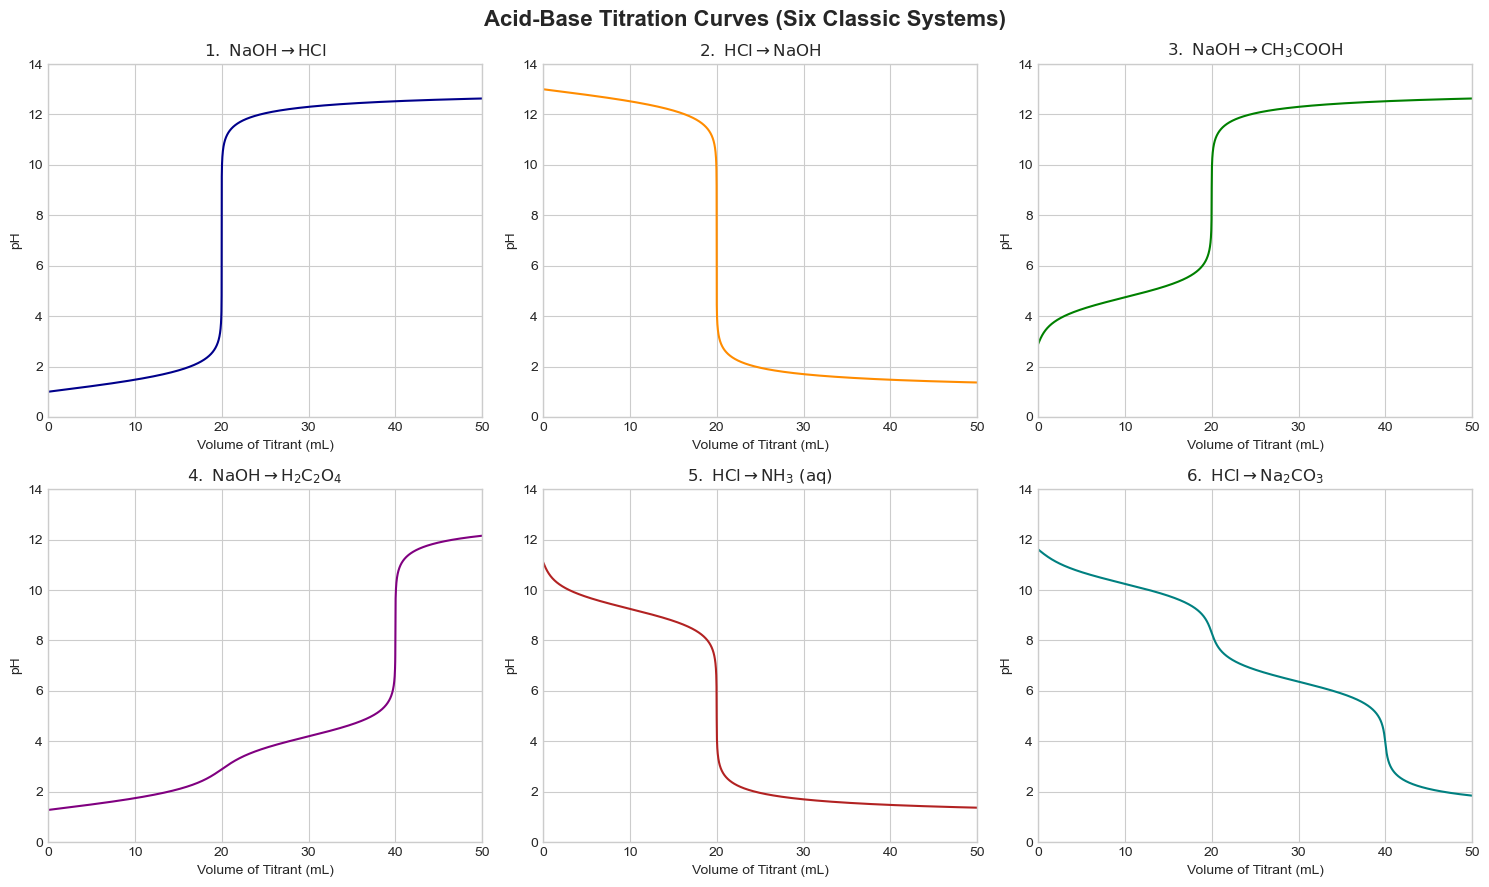

In [18]:
# --- 模拟与绘图控制框架 ---

# 碱滴定酸 (Vb 为自变量); 在 pH 上 brentq, 见正文第 4.3 节
def sim_base_titrant(res_func, Ca, Va, Cb, Vb_max, *args):
    Vb_array = np.linspace(0, Vb_max, 5000) 
    pH_list = []
    
    # 在 pH 上求 brentq: g(pH)=res(10^-pH), 见正文第 4.2--4.3 节. res_pH 定义在循环外, 避免每点重建函数对象.
    def res_pH(pH_val, current_Vb):
        H_sol = 10.0 ** (-pH_val)
        return res_func(H_sol, Ca, Va, Cb, current_Vb, *args)

    for Vb in Vb_array:
        try:
            pH_sol = brentq(res_pH, -1.0, 15.0, args=(Vb,))
            pH_list.append(pH_sol)
        except ValueError:
            pH_list.append(np.nan)
    return Vb_array, np.array(pH_list)

# 酸滴定碱 (Va 为自变量); 求根方式同 sim_base_titrant, 见第 4.3 节
def sim_acid_titrant(res_func, Ca, Va_max, Cb, Vb, *args):
    Va_array = np.linspace(0, Va_max, 5000)
    pH_list = []

    def res_pH(pH_val, current_Va):
        H_sol = 10.0 ** (-pH_val)
        return res_func(H_sol, Ca, current_Va, Cb, Vb, *args)
        
    for Va in Va_array:
        try:
            pH_sol = brentq(res_pH, -1.0, 15.0, args=(Va,))
            pH_list.append(pH_sol)
        except ValueError:
            pH_list.append(np.nan)
    return Va_array, np.array(pH_list)

# --- 生成数据并绘制 2x3 矩阵子图 ---
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Acid-Base Titration Curves (Six Classic Systems)", fontsize=16, fontweight='bold')

# 子图标题使用 Matplotlib 数学文本 (mathtext), 无需开启 text.usetex
# 1. NaOH 滴 HCl
V, pH = sim_base_titrant(res_NaOH_HCl, 0.1, 20.0, 0.1, 50.0)
axs[0, 0].plot(V, pH, color='darkblue')
axs[0, 0].set_title(r"$1.\ \mathrm{NaOH} \rightarrow \mathrm{HCl}$")

# 2. HCl 滴 NaOH
V, pH = sim_acid_titrant(res_HCl_NaOH, 0.1, 50.0, 0.1, 20.0)
axs[0, 1].plot(V, pH, color='darkorange')
axs[0, 1].set_title(r"$2.\ \mathrm{HCl} \rightarrow \mathrm{NaOH}$")

# 3. NaOH 滴醋酸
V, pH = sim_base_titrant(res_NaOH_CH3COOH, 0.1, 20.0, 0.1, 50.0, 1.8e-5)
axs[0, 2].plot(V, pH, color='green')
axs[0, 2].set_title(r"$3.\ \mathrm{NaOH} \rightarrow \mathrm{CH}_3\mathrm{COOH}$")

# 4. NaOH 滴草酸
V, pH = sim_base_titrant(res_NaOH_H2C2O4, 0.1, 20.0, 0.1, 50.0, 5.9e-2, 6.4e-5)
axs[1, 0].plot(V, pH, color='purple')
axs[1, 0].set_title(r"$4.\ \mathrm{NaOH} \rightarrow \mathrm{H}_2\mathrm{C}_2\mathrm{O}_4$")

# 5. HCl 滴氨水
V, pH = sim_acid_titrant(res_HCl_NH3, 0.1, 50.0, 0.1, 20.0, 1.8e-5)
axs[1, 1].plot(V, pH, color='firebrick')
axs[1, 1].set_title(r"$5.\ \mathrm{HCl} \rightarrow \mathrm{NH}_3\ (\mathrm{aq})$")

# 6. HCl 滴碳酸钠
V, pH = sim_acid_titrant(res_HCl_Na2CO3, 0.1, 50.0, 0.1, 20.0, 4.3e-7, 5.6e-11)
axs[1, 2].plot(V, pH, color='teal')
axs[1, 2].set_title(r"$6.\ \mathrm{HCl} \rightarrow \mathrm{Na}_2\mathrm{CO}_3$")

# 统一格式化坐标轴 (不绘制 pH=7 参考线, 避免与曲线混淆)
for ax in axs.flat:
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 14)
    ax.set_yticks(np.arange(0, 15, 2))
    ax.set(xlabel="Volume of Titrant (mL)", ylabel="pH")

plt.tight_layout()
plt.subplots_adjust(top=0.92) # 留出大标题空间
plt.show()


## 6. 数据可视化与结果分析

根据第 5 节运行生成的 6 种经典滴定体系的精准曲线图, 我们可以观察, 对比并总结出以下化学规律:

### 6.1 强酸强碱体系的对称性与巨大突跃
观察 **图 1** ($\ce{NaOH}$ 滴定 $\ce{HCl}$) 与 **图 2** ($\ce{HCl}$ 滴定 $\ce{NaOH}$):

- **突跃范围最大**: 在等当点 ($20\ \mathrm{mL}$) 附近, 仅增加不到 $0.1\ \mathrm{mL}$ 的滴定剂, $\mathrm{pH}$ 值就发生了断崖式突变(突跃范围极宽, 约为 $\mathrm{pH}\ 3.5 \sim 10.5$). 这使得强体系的滴定可以使用多种指示剂(如酚酞或甲基橙)来指示终点.
- **等当点呈严格中性**: 突跃曲线的拐点严格相交于 $\mathrm{pH} = 7.0$ 处, 因为反应生成的 $\ce{NaCl}$ 不发生水解.
- **完美的中心对称**: 强体系的方程由于不存在共轭酸碱对的缓冲效应, 图 1 与图 2 沿 $\mathrm{pH} = 7$ 和 $V = 20\ \mathrm{mL}$ 的中心点表现出完美的数学对称性.

### 6.2 弱体系的缓冲区域与等当点偏移
观察 **图 3** (滴定一元弱酸醋酸) 与 **图 5** (滴定一元弱碱氨水):

- **出现明显的缓冲区域**: 在滴定初期及中段($0 \sim 15\ \mathrm{mL}$ 区间), 由于生成了大量的共轭酸碱对 (如 $\ce{CH3COOH}/\ce{CH3COO-}$ 和 $\ce{NH4+}/\ce{NH3}$), 溶液构成了缓冲体系. 此时曲线切线斜率变缓, 溶液对 $\mathrm{pH}$ 的改变具有很强的抵抗作用. 特别是在半滴定点 ($10\ \mathrm{mL}$) 处, $\mathrm{pH} \approx pK_a$.
- **等当点偏移**: 
  - 强碱滴弱酸 (图 3) 的等当点不再是 7, 而是偏向碱性区域 ($\mathrm{pH} > 7$), 这是由于到达等当点时生成的醋酸钠发生水解显碱性.
  - 强酸滴弱碱 (图 5) 的等当点偏向酸性区域 ($\mathrm{pH} < 7$), 原因是生成的氯化铵发生水解显酸性.
- **突跃范围显著缩小**: 弱电解质的起始 $\mathrm{pH}$ 与等当点偏移导致突跃变短. 这在实验中要求指示剂的选择必须更加苛刻.

### 6.3 多元弱酸弱碱的分步滴定特征
观察 **图 4** (滴定二元弱酸草酸) 与 **图 6** (滴定二元弱碱碳酸钠):

- **多重等当点与阶梯状曲线**: 由于草酸和碳酸具有两级电离常数 ($K_{a1}, K_{a2}$), 每次质子的得失都对应着一个反应阶段, 图像上呈现出明显的双阶梯特征.
- **碳酸钠的双突跃 (图 6)**: 碳酸的两级电离常数差异极大 ($K_{a1} / K_{a2} > 10^4$), 因此曲线呈现出两个极其清晰独立的突跃段, 分别对应于 $\ce{CO3^{2-}} \to \ce{HCO3-}$ (约 $20\ \mathrm{mL}$ 处) 以及 $\ce{HCO3-} \to \ce{H2CO3}$ (约 $40\ \mathrm{mL}$ 处).
- **草酸的融合突跃 (图 4)**: 草酸的两级电离常数差异相对较小 ($K_{a1} \approx 10^{-2}, K_{a2} \approx 10^{-5}$). 正因如此, 第一个等当点 ($20\ \mathrm{mL}$ 处) 的突跃非常不明显, 几乎与第二个突跃区融合; 直到第二个等当点 ($40\ \mathrm{mL}$ 处) 被完全中和时才出现陡峭的突跃. 这恰好证明了本实验数值求解模型极其强大: 它**无须依靠经验法则强行截断, 也能精准捕捉到这种极难用解析公式计算的平滑过渡特征**.

## 7. 实验结论

1. **统一的守恒建模超越了传统近似**: 本实验成功证实, 完全可以抛弃传统教材中的"最简式"和繁琐的分段近似运算. 仅仅通过联立**物料守恒**, **电荷守恒**与**水的自偶电离**三个基本化学定律, 就能构建出涵盖整个滴定生命周期的精确非线性代数方程组.
2. **重参数化与数值算法构成的降维打击**: 通过将基于微观浓度 $[\ce{H+}]$ 的求解转化为宏观 $\mathrm{pH}$ 域的对数寻根 (即解除了强非线性引起的刚性灾难), 并借助 Python 科学计算库强大的数值寻根算法, 我们轻而易举地重现了经典化学教材中的完整体系.
3. **理论预测与物理直觉的完美契合**: 模型生成的曲线无论是缓冲容量, 等当点偏移方向, 还是分步解离阶梯, 都与真实实验体系表现出令人惊叹的一致性. 计算化学的引入, 使得化学平衡教学从枯燥的死记硬背进化为了严密而优雅的数据科学工程.
